# Random Walk: theory, simulation, and first hitting time

This is the first completed experiment in Stochastic Processes Lab. Run the cells from top to bottom. All simulations use explicit fixed seeds; all reported numbers and plots are generated by these cells.

## 1. Problem

Let $S_0=0$ and $S_n=\sum_{i=1}^{n}X_i$, where the independent increments satisfy $P(X_i=1)=P(X_i=-1)=1/2$. We ask:

1. What are $E[S_n]$ and $\operatorname{Var}(S_n)$?
2. At a fixed $n=100$, how do empirical endpoint mean and variance change as the number of independent paths increases through 10, 100, 1,000, and 10,000?
3. For $T_{10}=\inf\{n\geq 0:S_n=10\}$, what does a finite simulation tell us about the time to first hit $+10$?

The path count $M$ and step count $n$ play different roles: increasing $M$ improves estimation at a fixed time, while increasing $n$ changes the theoretical distribution itself.

## 2. Mathematical Background

For one increment, $E[X_i]=(1)(1/2)+(-1)(1/2)=0$. Since $X_i^2=1$, $\operatorname{Var}(X_i)=E[X_i^2]-E[X_i]^2=1$.

Linearity of expectation gives $E[S_n]=\sum_i E[X_i]$. Independence makes all covariance terms zero, so

$$\operatorname{Var}(S_n)=\sum_{i=1}^n\operatorname{Var}(X_i)+2\sum_{i<j}\operatorname{Cov}(X_i,X_j)=n.$$

If $B_n$ counts the $+1$ steps, then $B_n\sim\operatorname{Binomial}(n,1/2)$ and $S_n=2B_n-n$. Thus $S_n$ only takes values with the same parity as $n$. This exact distribution is useful for checking the endpoint histogram.

For $M$ paths, we estimate variance with the sample variance $\widehat v=(M-1)^{-1}\sum_{j=1}^{M}(S_n^{(j)}-\overline S_n)^2$. We use $M-1$ so this estimator is unbiased. The standard deviation of the sample mean is $\sqrt{n/M}$; small samples can therefore be far from zero without contradicting the theory.

## 3. Theoretical Result

$$\boxed{E[S_n]=0,\qquad \operatorname{Var}(S_n)=n.}$$

At $n=100$, the target mean is **0** and the target variance is **100**. The exact endpoint probabilities are

$$P(S_n=2k-n)=\binom nk 2^{-n},\qquad k=0,\ldots,n.$$

Write $T_c$ for the first visit to level $c$. The first hitting time $T_{10}$ is finite with probability one, but **$E[T_{10}]=\infty$**. These are different statements. For eventual hitting, the gambler's-ruin calculation gives $P_0(T_{10}<T_{-b})=b/(10+b)$. Letting $b\to\infty$ shows $P_0(T_{10}<\infty)=1$.

To see why the mean is nevertheless infinite, suppose $m_i=E_i[T_{10}]$ were finite starting from $i=0$. The first-step equation $m_i=1+(m_{i-1}+m_{i+1})/2$ would then force finite values for every $i\leq10$, with $m_{10}=0$. Its general solution is $m_i=-i^2+Ai+B$, which becomes negative as $i\to-\infty$. An expected time cannot be negative, so the finite-mean assumption is impossible. Equivalently, the first-passage survival probability has a slowly decaying tail of order $n^{-1/2}$, whose sum diverges.

A run stopped after a finite number of steps reports right-censored paths; it cannot estimate this infinite expectation by averaging only observed hits.

## 4. Numerical Experiment

In [1]:
from math import comb, ceil
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "src" / "random_walk.py").exists(), "Run from the repository root or notebooks/"
sys.path.insert(0, str(project_root))

from src.random_walk import endpoint_statistics, simulate_first_hitting_times, simulate_random_walk

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)
n_steps = 100
sample_sizes = (10, 100, 1_000, 10_000)
paths = simulate_random_walk(n_steps, max(sample_sizes), np.random.default_rng(20260924))
endpoints = paths[:, -1]
summaries = [(m, *endpoint_statistics(endpoints[:m])) for m in sample_sizes]

print(f"Theory at n={n_steps}: mean = 0, variance = {n_steps}")
print(f"{'paths':>8} {'sample mean':>14} {'sample variance':>17} {'mean error':>14} {'variance error':>17}")
for m, mean, variance in summaries:
    print(f"{m:8,d} {mean:14.3f} {variance:17.3f} {abs(mean):14.3f} {abs(variance-n_steps):17.3f}")

Matplotlib is building the font cache; this may take a moment.


Theory at n=100: mean = 0, variance = 100
   paths    sample mean   sample variance     mean error    variance error
      10         -4.400            62.044          4.400            37.956
     100          0.360            98.697          0.360             1.303
   1,000          0.528           108.294          0.528             8.294
  10,000          0.046           100.172          0.046             0.172


The four rows use nested prefixes of one fixed set of independent paths. This makes the effect of increasing the path count easy to inspect. Convergence is a long-run tendency, not a guarantee that every larger row is closer to theory.

For first passage, we simulate 2,000 new paths with a separate seed, stopping each path once it reaches $+10$ or reaches 20,000 steps. A value of `-1` marks a path whose hitting time exceeds the step limit.

In [2]:
level = 10
hit_path_count = 2_000
max_steps = 20_000
hitting_times = simulate_first_hitting_times(
    level, hit_path_count, max_steps, np.random.default_rng(20260925)
)
observed_hits = np.sort(hitting_times[hitting_times >= 0])
censored_count = hit_path_count - observed_hits.size

print(f"Reached +{level} by {max_steps:,} steps: {observed_hits.size:,}/{hit_path_count:,} "
      f"({observed_hits.size / hit_path_count:.1%})")
print(f"Not yet reached +{level} at the limit: {censored_count:,} paths")
for q in (0.25, 0.50, 0.75):
    rank = ceil(q * hit_path_count)
    if observed_hits.size >= rank:
        print(f"Empirical {q:.0%} hitting-time quantile: {observed_hits[rank - 1]:,} steps")
    else:
        print(f"Empirical {q:.0%} hitting-time quantile: beyond {max_steps:,} steps")

Reached +10 by 20,000 steps: 1,892/2,000 (94.6%)
Not yet reached +10 at the limit: 108 paths
Empirical 25% hitting-time quantile: 70 steps
Empirical 50% hitting-time quantile: 212 steps
Empirical 75% hitting-time quantile: 906 steps


## 5. Visualization

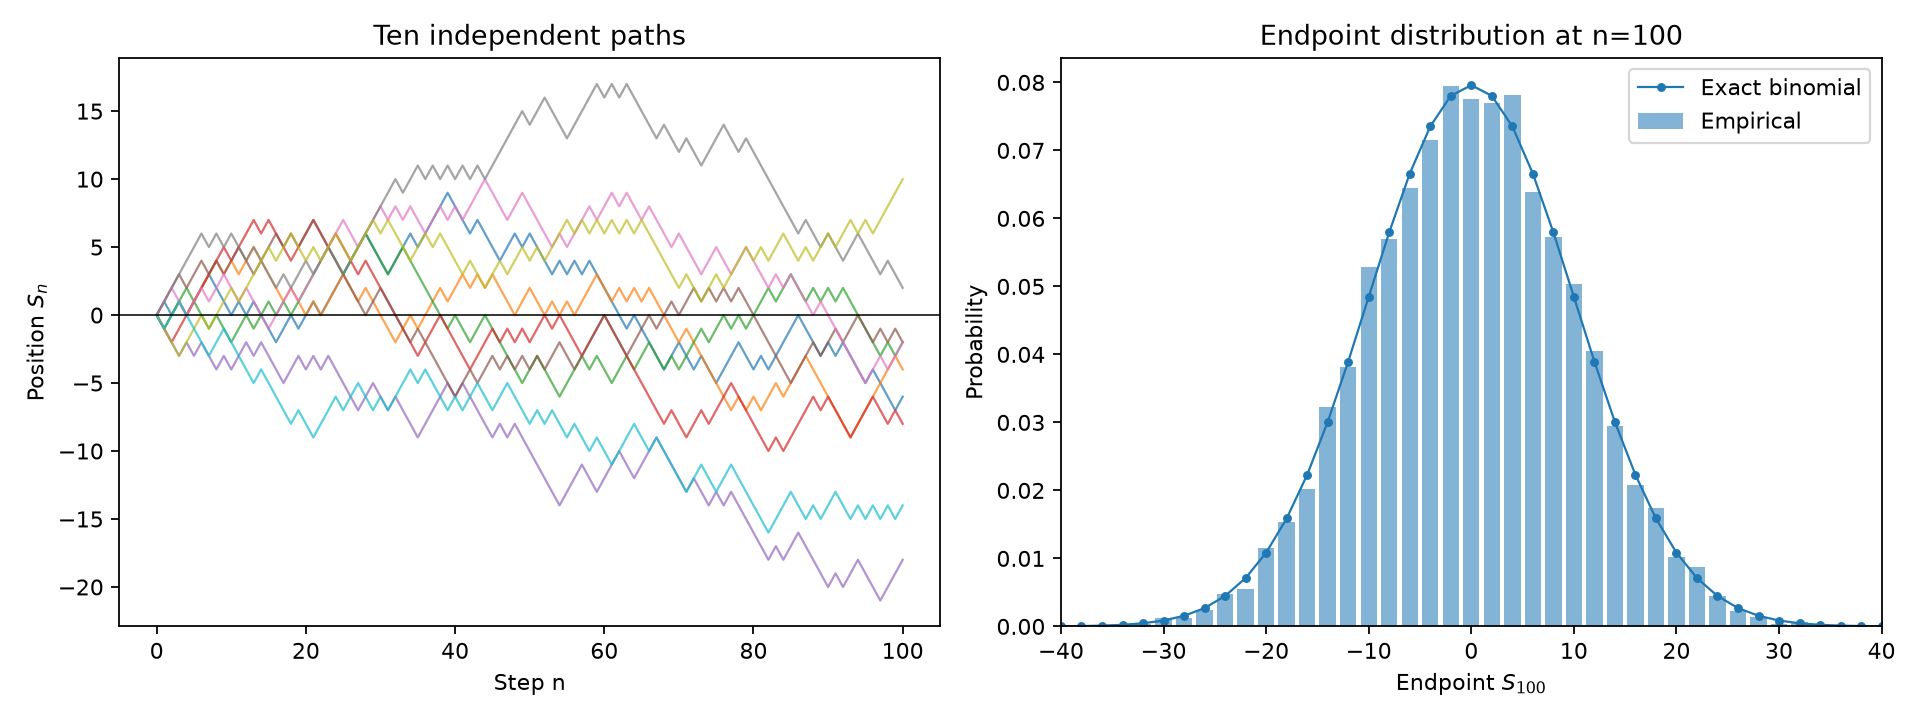

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for path in paths[:10]:
    axes[0].plot(range(n_steps + 1), path, alpha=0.7, linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.7)
axes[0].set(title="Ten independent paths", xlabel="Step n", ylabel=r"Position $S_n$")

values, counts = np.unique(endpoints, return_counts=True)
theory_values = np.arange(-n_steps, n_steps + 1, 2)
theory_probabilities = np.array([comb(n_steps, (value + n_steps) // 2) * 0.5**n_steps
                                 for value in theory_values])
axes[1].bar(values, counts / endpoints.size, width=1.6, alpha=0.55, label="Empirical")
axes[1].plot(theory_values, theory_probabilities, "o-", markersize=3, linewidth=1,
             label="Exact binomial")
axes[1].set(title="Endpoint distribution at n=100", xlabel=r"Endpoint $S_{100}$",
            ylabel="Probability")
axes[1].set_xlim(-40, 40)  # Focus on the region with visible probability mass.
axes[1].legend()
fig.tight_layout()
path = figure_dir / "random_walk_paths_and_distribution.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

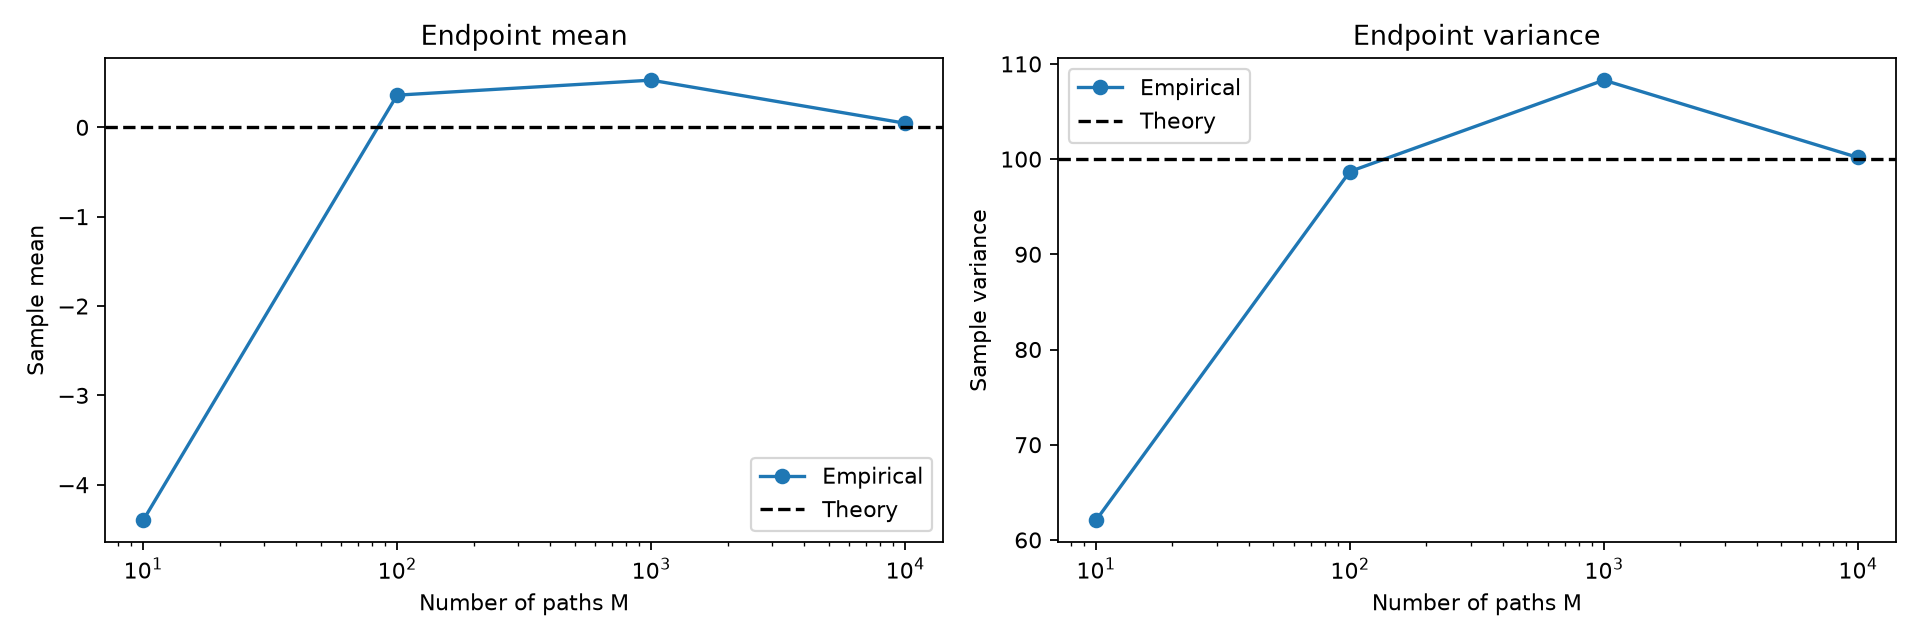

In [4]:
counts_m = np.array([row[0] for row in summaries])
means = np.array([row[1] for row in summaries])
variances = np.array([row[2] for row in summaries])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(counts_m, means, "o-", label="Empirical")
axes[0].axhline(0, color="black", linestyle="--", label="Theory")
axes[0].set(title="Endpoint mean", xlabel="Number of paths M", ylabel="Sample mean", xscale="log")
axes[0].legend()
axes[1].plot(counts_m, variances, "o-", label="Empirical")
axes[1].axhline(n_steps, color="black", linestyle="--", label="Theory")
axes[1].set(title="Endpoint variance", xlabel="Number of paths M",
            ylabel="Sample variance", xscale="log")
axes[1].legend()
fig.tight_layout()
path = figure_dir / "random_walk_moment_convergence.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

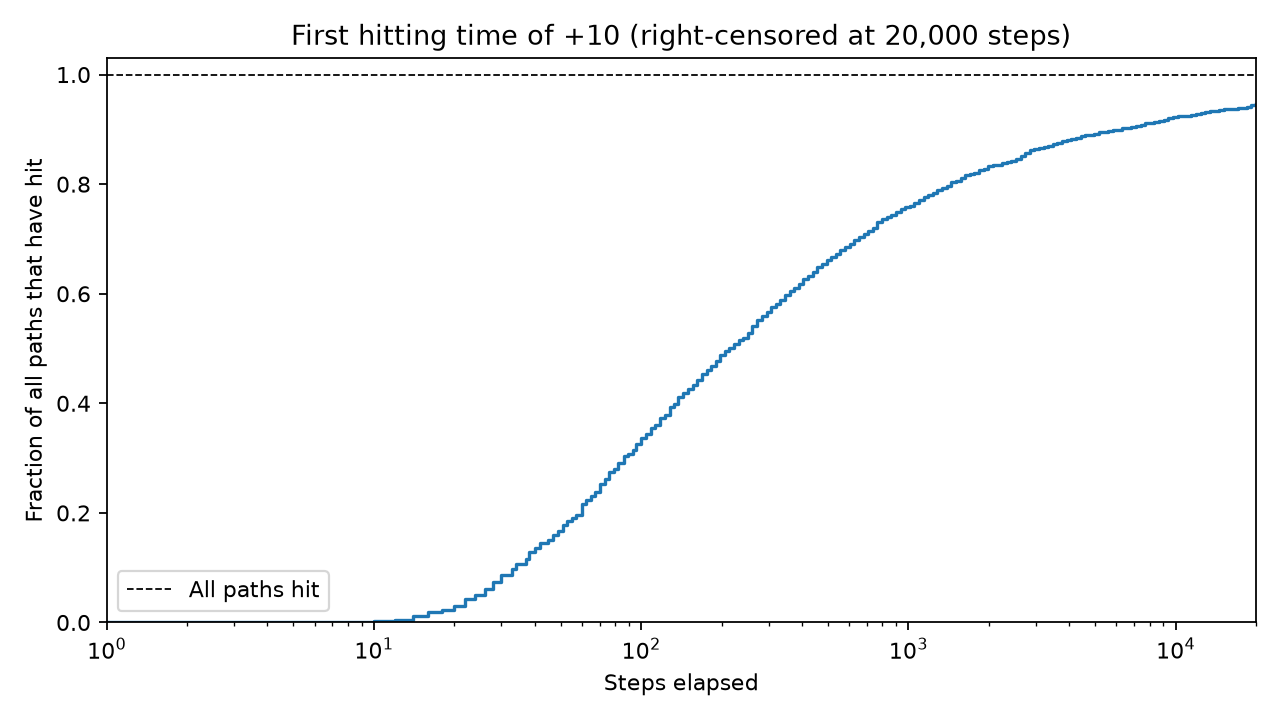

In [5]:
time_grid = np.unique(np.r_[0, np.geomspace(1, max_steps, 250).astype(int), max_steps])
hit_fraction = np.searchsorted(observed_hits, time_grid, side="right") / hit_path_count
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.step(time_grid[1:], hit_fraction[1:], where="post")
ax.axhline(1, color="black", linestyle="--", linewidth=0.8, label="All paths hit")
ax.set(xscale="log", xlim=(1, max_steps), ylim=(0, 1.03),
       title="First hitting time of +10 (right-censored at 20,000 steps)",
       xlabel="Steps elapsed", ylabel="Fraction of all paths that have hit")
ax.legend()
fig.tight_layout()
path = figure_dir / "random_walk_first_hitting_time.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

## 6. Comparison with Theory

Compare the table with $(0,100)$ and the endpoint frequencies with the exact binomial probabilities. The sample mean's typical scale is $\sqrt{100/M}$: about $3.16$ for $M=10$ and $0.10$ for $M=10{,}000$. A sample can be outside these typical scales, and the error need not shrink at every successive row. The variance estimator is also random, even though its expectation is 100.

The first-passage curve uses **all** paths in its denominator. Its value at 20,000 is the fraction observed to hit by that limit; paths still unfinished are right-censored. The plotted curve makes no claim that the eventual hit probability is less than one.

## 7. Interpretation

The distribution plot checks more than two moments: it checks the shape and lattice spacing predicted by $S_n=2B_n-n$. The moment plots show how increasing the number of independent paths stabilizes empirical estimates at the fixed time $n=100$.

For the hitting-time question, a quantile gives a useful notion of a “typical” wait. There is no finite theoretical mean wait to compare with: $E[T_{10}]=\infty$. In particular, the mean of only the paths that hit before the simulation stops would be biased by the cutoff, so it is deliberately omitted.

## 8. Limitations

- Pseudorandom draws are reproducible because their seeds are fixed, but they are still one realization of a random experiment.
- The endpoint study fixes $n=100$; changing $n$ changes the target variance and exact distribution.
- The hitting-time run has a finite 20,000-step horizon. A censored path may hit later; the simulation does not establish the infinite-mean result, which comes from theory.
- With only 2,000 first-passage paths, extreme tail probabilities and high quantiles are noisy. Larger horizons and repeated runs would be needed for a more detailed tail study.